<a href="https://colab.research.google.com/github/Aki-max-min/Self_Pruning_NeuralNetwork/blob/main/Self_Pruning_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

!pip install torch torchvision matplotlib seaborn -q

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from copy import deepcopy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                           shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset, batch_size=256,
                                           shuffle=False, num_workers=2)

print(f"Train size: {len(trainset)}, Test size: {len(testset)}")

100%|██████████| 170M/170M [00:03<00:00, 43.1MB/s]


Train size: 50000, Test size: 10000


In [4]:


class PrunableLinear(nn.Module):
    """
    Linear layer where each weight is multiplied by a learnable sigmoid gate.
    Effective weight: W' = W * sigmoid(G)
    Gate scores G are initialized slightly positive so training starts
    with ~73% active connections, giving the sparsity penalty room to prune.
    """
    def __init__(self, in_features, out_features, gate_init=1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(
            torch.full((out_features, in_features), gate_init)
        )

        nn.init.kaiming_uniform_(self.weight, a=0.01)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        effective_weight = self.weight * gates
        return nn.functional.linear(x, effective_weight, self.bias)

    def get_sparsity(self, threshold=0.5):
        """Fraction of gates below threshold (effectively pruned)."""
        gates = torch.sigmoid(self.gate_scores)
        return (gates < threshold).float().mean().item()

    def hard_prune(self, threshold=0.5):
        """Zero out weights whose gate < threshold (in-place, no grad)."""
        with torch.no_grad():
            gates = torch.sigmoid(self.gate_scores)
            mask = (gates >= threshold).float()
            self.weight.data *= mask

    def get_gate_values(self):
        return torch.sigmoid(self.gate_scores).detach().cpu().numpy()

In [5]:


class SelfPruningNet(nn.Module):
    def __init__(self, gate_init=1.0):
        super().__init__()

        self.backbone = nn.Sequential(

            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),


            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),


            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )


        self.fc1     = PrunableLinear(256, 256, gate_init=gate_init)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.fc2     = PrunableLinear(256, 10, gate_init=gate_init)

    def forward(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

    def sparsity_loss(self):
        """Sum of all gate values (penalizes keeping connections active)."""
        total = 0.0
        for m in [self.fc1, self.fc2]:
            total += torch.sigmoid(m.gate_scores).sum()
        return total

    def get_layer_sparsities(self, threshold=0.5):
        return {
            'fc1': self.fc1.get_sparsity(threshold),
            'fc2': self.fc2.get_sparsity(threshold),
        }

    def hard_prune_all(self, threshold=0.5):
        self.fc1.hard_prune(threshold)
        self.fc2.hard_prune(threshold)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

_m = SelfPruningNet()
_x = torch.randn(4, 3, 32, 32)
print("Output shape:", _m(_x).shape)
print("Total trainable params:", count_params(_m))

Output shape: torch.Size([4, 10])
Total trainable params: 693066


In [6]:


def get_optimizer(model, lr=1e-3, weight_decay=1e-4):
    """Separate param groups: weight decay for weights, none for gates."""
    gate_params   = [p for n, p in model.named_parameters() if 'gate_scores' in n]
    normal_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]
    return optim.Adam([
        {'params': normal_params, 'weight_decay': weight_decay},
        {'params': gate_params,   'weight_decay': 0.0},
    ], lr=lr)


def train_one_epoch(model, loader, optimizer, criterion,
                    lam, lam_scale, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        ce_loss = criterion(outputs, labels)
        sp_loss = model.sparsity_loss()
        loss = ce_loss + lam * lam_scale * sp_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total   += inputs.size(0)
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            correct += outputs.argmax(1).eq(labels).sum().item()
            total   += inputs.size(0)
    return 100.0 * correct / total


def train_model(lam, epochs=30, warmup_epochs=5,
                gate_init=1.0, lr=1e-3, device=device):
    """
    Train a SelfPruningNet with sparsity coefficient `lam`.
    Lambda is warmed up linearly over `warmup_epochs`.
    """
    model = SelfPruningNet(gate_init=gate_init).to(device)
    optimizer = get_optimizer(model, lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history = {'train_acc': [], 'test_acc': [], 'sparsity_fc1': [],
               'sparsity_fc2': [], 'mean_gate': [], 'loss': []}

    for epoch in range(1, epochs + 1):

        lam_scale = min(1.0, epoch / warmup_epochs)

        train_loss, train_acc = train_one_epoch(
            model, trainloader, optimizer, criterion,
            lam, lam_scale, device
        )
        test_acc = evaluate(model, testloader, device)
        sparsities = model.get_layer_sparsities(threshold=0.5)
        mean_gate = np.mean([
            model.fc1.get_gate_values().mean(),
            model.fc2.get_gate_values().mean()
        ])

        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['sparsity_fc1'].append(sparsities['fc1'])
        history['sparsity_fc2'].append(sparsities['fc2'])
        history['mean_gate'].append(mean_gate)
        history['loss'].append(train_loss)
        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f"[λ={lam:.0e}] Epoch {epoch:02d}/{epochs} | "
                  f"Loss: {train_loss:.3f} | TrainAcc: {train_acc:.1f}% | "
                  f"TestAcc: {test_acc:.1f}% | "
                  f"Sparsity fc1: {sparsities['fc1']*100:.1f}% "
                  f"fc2: {sparsities['fc2']*100:.1f}%")

    return model, history

In [7]:


LAMBDAS = [1e-4, 5e-4, 2e-3]
EPOCHS  = 30

results = {}

for lam in LAMBDAS:
    print(f"\n{'='*60}")
    print(f"Training with λ = {lam:.0e}")
    print('='*60)
    model, history = train_model(lam=lam, epochs=EPOCHS,
                                  warmup_epochs=5, gate_init=1.0)

    soft_acc      = history['test_acc'][-1]
    soft_sparsity = np.mean([history['sparsity_fc1'][-1],
                              history['sparsity_fc2'][-1]])

    hard_model = deepcopy(model)
    hard_model.hard_prune_all(threshold=0.5)
    hard_acc      = evaluate(hard_model, testloader, device)
    hard_sparsity = np.mean([hard_model.fc1.get_sparsity(),
                              hard_model.fc2.get_sparsity()])

    results[lam] = {
        'model':          model,
        'hard_model':     hard_model,
        'history':        history,
        'soft_acc':       soft_acc,
        'soft_sparsity':  soft_sparsity,
        'hard_acc':       hard_acc,
        'hard_sparsity':  hard_sparsity,
    }
    print(f"\nSummary — λ={lam:.0e}: "
          f"Soft Acc={soft_acc:.1f}% Sparsity={soft_sparsity*100:.1f}% | "
          f"Hard Acc={hard_acc:.1f}% Sparsity={hard_sparsity*100:.1f}%")


Training with λ = 1e-04
[λ=1e-04] Epoch 01/30 | Loss: 2.384 | TrainAcc: 48.5% | TestAcc: 57.1% | Sparsity fc1: 0.0% fc2: 0.0%
[λ=1e-04] Epoch 05/30 | Loss: 4.055 | TrainAcc: 77.1% | TestAcc: 71.8% | Sparsity fc1: 48.5% fc2: 19.7%
[λ=1e-04] Epoch 10/30 | Loss: 2.437 | TrainAcc: 84.3% | TestAcc: 81.7% | Sparsity fc1: 87.8% fc2: 30.8%
[λ=1e-04] Epoch 15/30 | Loss: 1.710 | TrainAcc: 88.2% | TestAcc: 84.5% | Sparsity fc1: 96.7% fc2: 36.4%
[λ=1e-04] Epoch 20/30 | Loss: 1.348 | TrainAcc: 90.8% | TestAcc: 87.0% | Sparsity fc1: 98.3% fc2: 39.1%
[λ=1e-04] Epoch 25/30 | Loss: 1.180 | TrainAcc: 93.2% | TestAcc: 88.6% | Sparsity fc1: 98.7% fc2: 40.2%
[λ=1e-04] Epoch 30/30 | Loss: 1.131 | TrainAcc: 94.1% | TestAcc: 88.6% | Sparsity fc1: 98.8% fc2: 40.4%

Summary — λ=1e-04: Soft Acc=88.6% Sparsity=69.6% | Hard Acc=75.7% Sparsity=69.6%

Training with λ = 5e-04
[λ=5e-04] Epoch 01/30 | Loss: 6.217 | TrainAcc: 47.7% | TestAcc: 47.3% | Sparsity fc1: 0.0% fc2: 0.0%
[λ=5e-04] Epoch 05/30 | Loss: 11.505 | T

In [8]:


print(f"\n{'='*75}")
print(f"{'Lambda':<10} {'Test Acc':>10} {'Sparsity':>12} "
      f"{'Hard Acc':>12} {'Hard Sparsity':>15}")
print(f"{'-'*75}")
for lam in LAMBDAS:
    r = results[lam]
    print(f"{lam:<10.0e} {r['soft_acc']:>9.2f}% {r['soft_sparsity']*100:>11.1f}% "
          f"{r['hard_acc']:>11.2f}% {r['hard_sparsity']*100:>14.1f}%")
print(f"{'='*75}")


Lambda       Test Acc     Sparsity     Hard Acc   Hard Sparsity
---------------------------------------------------------------------------
1e-04          88.63%        69.6%       75.69%           69.6%
5e-04          88.36%        92.3%       10.00%           92.3%
2e-03          87.92%        99.8%       10.00%           99.8%


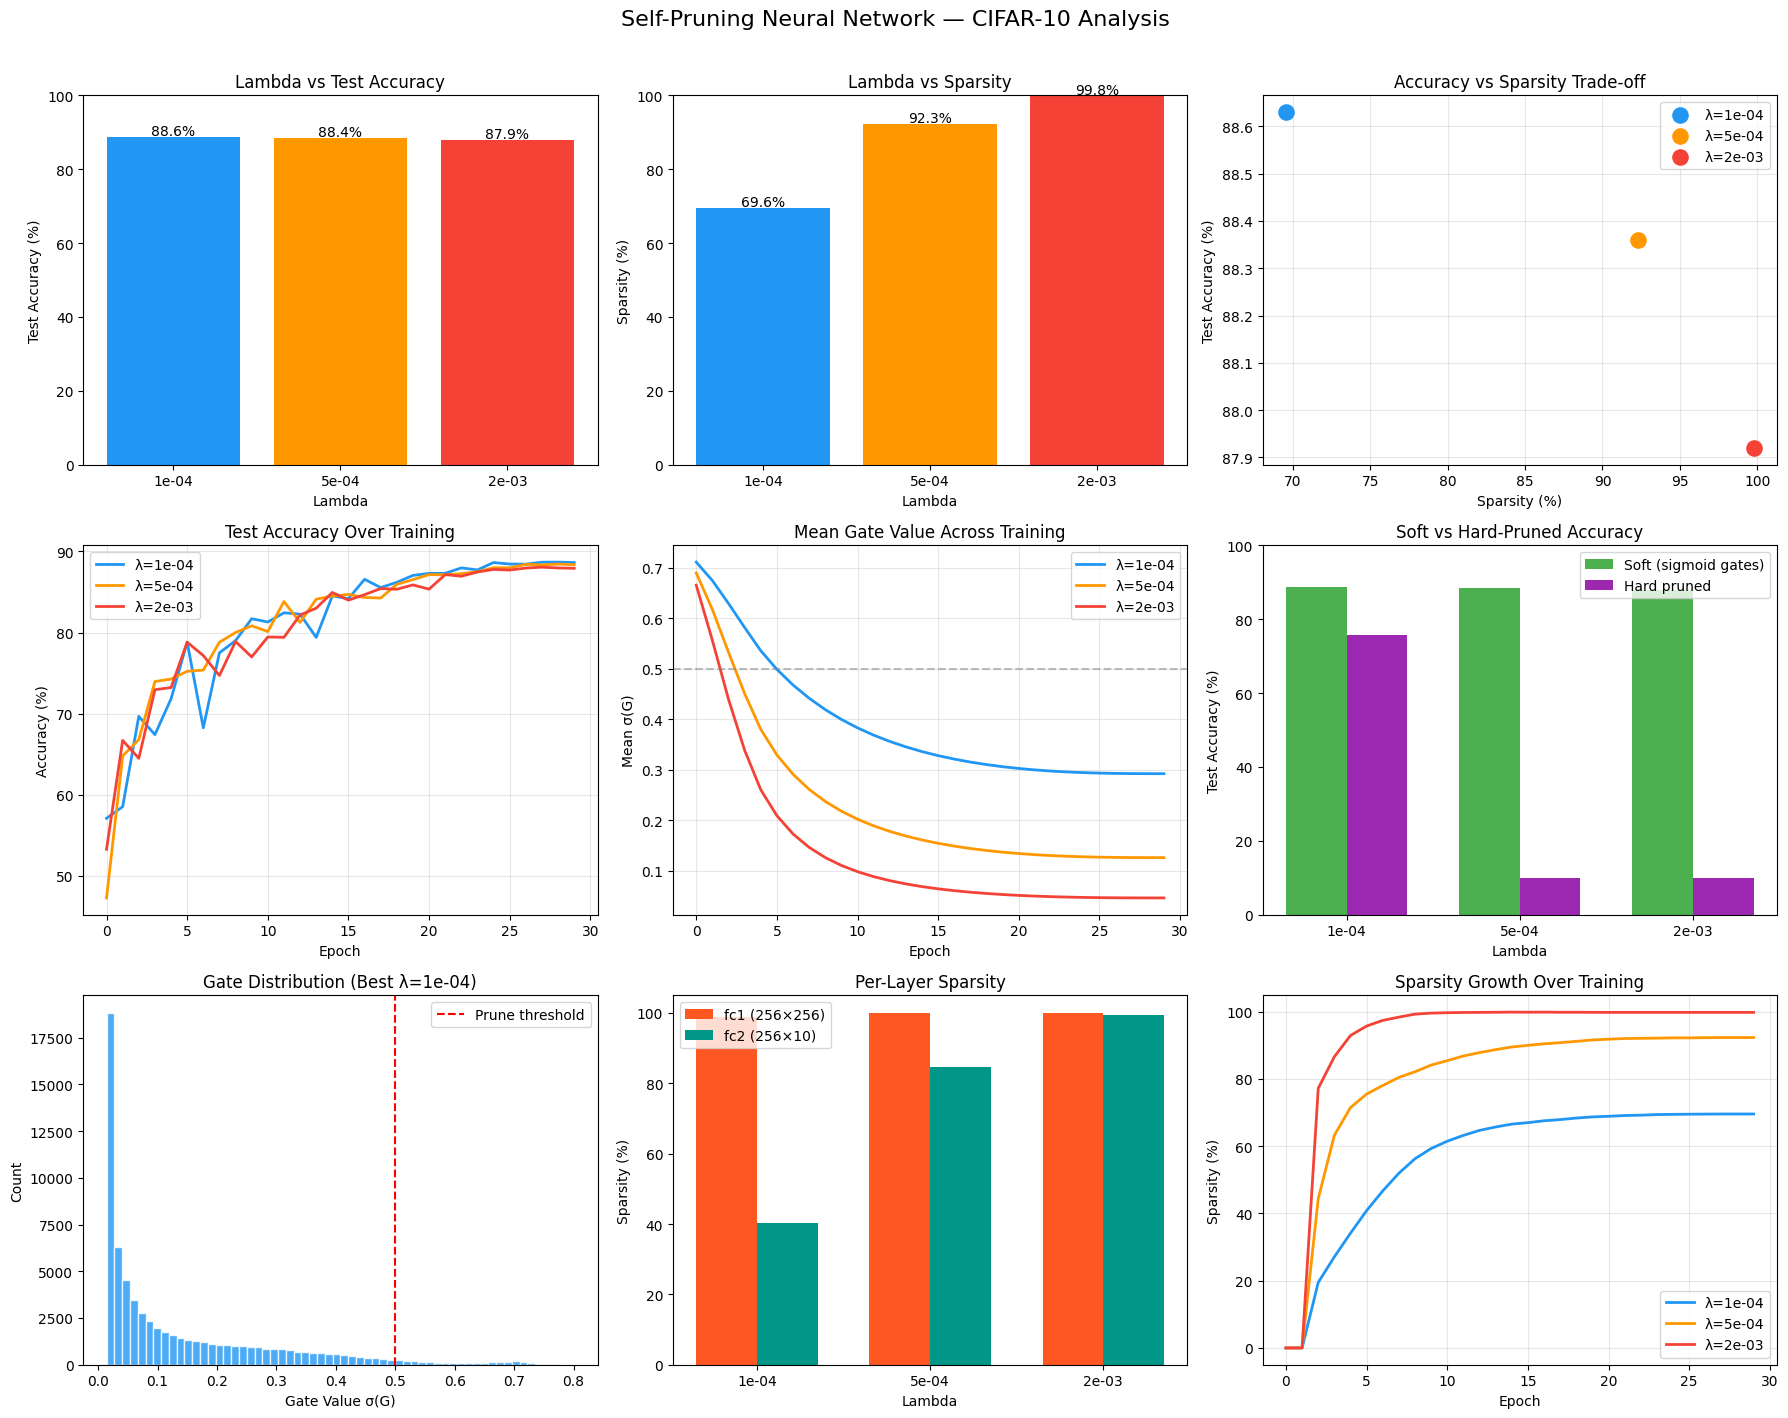

Plot saved as pruning_analysis.png


In [9]:


fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Self-Pruning Neural Network — CIFAR-10 Analysis", fontsize=16, y=1.01)
colors = ['#2196F3', '#FF9800', '#F44336']

ax = axes[0, 0]
accs = [results[l]['soft_acc'] for l in LAMBDAS]
bars = ax.bar([f"{l:.0e}" for l in LAMBDAS], accs, color=colors)
ax.set_title("Lambda vs Test Accuracy")
ax.set_xlabel("Lambda"); ax.set_ylabel("Test Accuracy (%)")
ax.set_ylim(0, 100)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', fontsize=10)

ax = axes[0, 1]
sparsities = [results[l]['soft_sparsity'] * 100 for l in LAMBDAS]
bars = ax.bar([f"{l:.0e}" for l in LAMBDAS], sparsities, color=colors)
ax.set_title("Lambda vs Sparsity")
ax.set_xlabel("Lambda"); ax.set_ylabel("Sparsity (%)")
ax.set_ylim(0, 100)
for bar, sp in zip(bars, sparsities):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{sp:.1f}%', ha='center', fontsize=10)

ax = axes[0, 2]
for i, lam in enumerate(LAMBDAS):
    r = results[lam]
    ax.scatter(r['soft_sparsity']*100, r['soft_acc'],
               color=colors[i], s=120, zorder=5, label=f'λ={lam:.0e}')
ax.set_title("Accuracy vs Sparsity Trade-off")
ax.set_xlabel("Sparsity (%)"); ax.set_ylabel("Test Accuracy (%)")
ax.legend(); ax.grid(True, alpha=0.3)


ax = axes[1, 0]
for i, lam in enumerate(LAMBDAS):
    ax.plot(results[lam]['history']['test_acc'],
            color=colors[i], label=f'λ={lam:.0e}', linewidth=2)
ax.set_title("Test Accuracy Over Training")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.legend(); ax.grid(True, alpha=0.3)


ax = axes[1, 1]
for i, lam in enumerate(LAMBDAS):
    ax.plot(results[lam]['history']['mean_gate'],
            color=colors[i], label=f'λ={lam:.0e}', linewidth=2)
ax.set_title("Mean Gate Value Across Training")
ax.set_xlabel("Epoch"); ax.set_ylabel("Mean σ(G)")
ax.legend(); ax.grid(True, alpha=0.3)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='threshold=0.5')

ax = axes[1, 2]
x = np.arange(len(LAMBDAS))
w = 0.35
soft_accs = [results[l]['soft_acc'] for l in LAMBDAS]
hard_accs = [results[l]['hard_acc'] for l in LAMBDAS]
ax.bar(x - w/2, soft_accs, w, label='Soft (sigmoid gates)', color='#4CAF50')
ax.bar(x + w/2, hard_accs, w, label='Hard pruned',         color='#9C27B0')
ax.set_title("Soft vs Hard-Pruned Accuracy")
ax.set_xticks(x); ax.set_xticklabels([f"{l:.0e}" for l in LAMBDAS])
ax.set_xlabel("Lambda"); ax.set_ylabel("Test Accuracy (%)")
ax.legend(); ax.set_ylim(0, 100)

best_lam = max(LAMBDAS, key=lambda l: results[l]['soft_acc'])
ax = axes[2, 0]
best_model = results[best_lam]['model']
all_gates = np.concatenate([
    best_model.fc1.get_gate_values().flatten(),
    best_model.fc2.get_gate_values().flatten()
])
ax.hist(all_gates, bins=60, color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', label='Prune threshold')
ax.set_title(f"Gate Distribution (Best λ={best_lam:.0e})")
ax.set_xlabel("Gate Value σ(G)"); ax.set_ylabel("Count")
ax.legend()

ax = axes[2, 1]
fc1_sp = [results[l]['history']['sparsity_fc1'][-1] * 100 for l in LAMBDAS]
fc2_sp = [results[l]['history']['sparsity_fc2'][-1] * 100 for l in LAMBDAS]
ax.bar(x - w/2, fc1_sp, w, label='fc1 (256×256)', color='#FF5722')
ax.bar(x + w/2, fc2_sp, w, label='fc2 (256×10)',  color='#009688')
ax.set_title("Per-Layer Sparsity")
ax.set_xticks(x); ax.set_xticklabels([f"{l:.0e}" for l in LAMBDAS])
ax.set_xlabel("Lambda"); ax.set_ylabel("Sparsity (%)"); ax.legend()

ax = axes[2, 2]
for i, lam in enumerate(LAMBDAS):
    sp = [np.mean([f1, f2]) * 100
          for f1, f2 in zip(results[lam]['history']['sparsity_fc1'],
                             results[lam]['history']['sparsity_fc2'])]
    ax.plot(sp, color=colors[i], label=f'λ={lam:.0e}', linewidth=2)
ax.set_title("Sparsity Growth Over Training")
ax.set_xlabel("Epoch"); ax.set_ylabel("Sparsity (%)")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pruning_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as pruning_analysis.png")

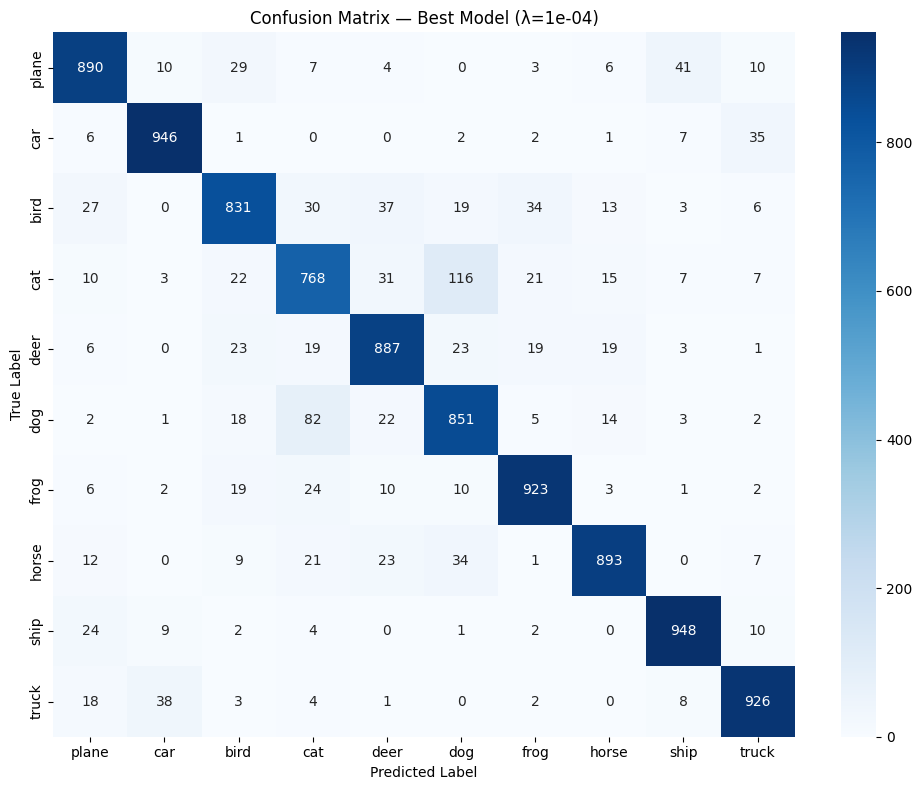

In [10]:


from sklearn.metrics import confusion_matrix

classes = ['plane','car','bird','cat','deer',
           'dog','frog','horse','ship','truck']

best_model = results[best_lam]['model'].eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs = inputs.to(device)
        preds  = best_model(inputs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title(f"Confusion Matrix — Best Model (λ={best_lam:.0e})")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()